# Rae2822 2D Wing Slice Model

### Import Library

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [2]:
# angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"
angles = sorted(glob.glob(f"{folder_path}*"), key=lambda x: float(x.split('\\')[-1]))
files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filepath in enumerate(angles):
    df = pd.read_csv(filepath+"/surface_flow.csv")

    # apply angles for each case
    df['AoA'] = float(angles[i].split('\\')[-1])

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


Empty DataFrame
Columns: [Pressure_Coefficient, AoA, x, y]
Index: []


In [3]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head()

Total rows: 8640


,Pressure_Coefficient,AoA,x,y
0,0.264443,-1.0,0.985397,0.000943
1,0.277211,-1.0,0.969573,0.001489
2,0.287710,-1.0,0.952680,0.001679
3,0.288603,-1.0,0.934996,0.001511
4,0.284074,-1.0,0.916822,0.000923


Text(0.5, 1.0, 'Sample Case: AoA = 0.0°')

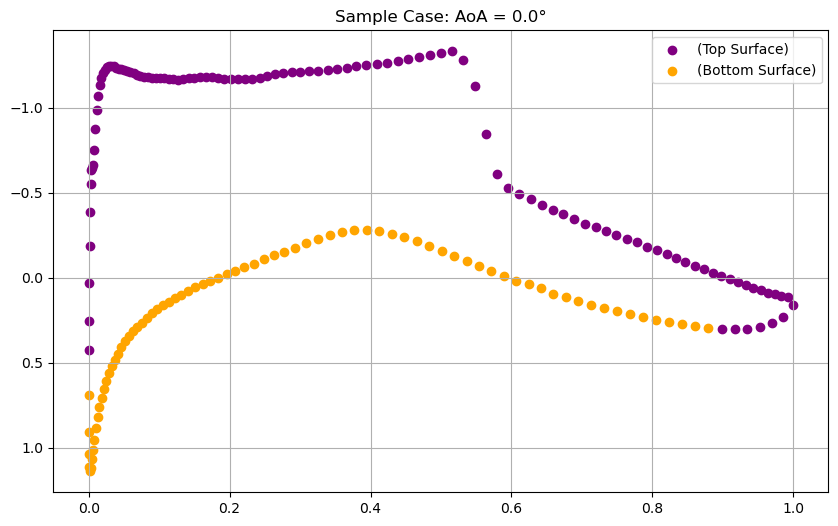

In [46]:
sample_case = full_data[full_data['AoA'] == 3.0]

plt.figure(figsize=(10, 6))
top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.title("Sample Case: AoA = 0.0°")

# Model

In [5]:
# import model
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
features = ['x', 'y', 'AoA']
target = 'Pressure_Coefficient'

In [14]:
logo = LeaveOneGroupOut()

architecture = [
        tf.keras.layers.Dense(64, activation='relu', input_shape=(3,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1)
    ]

aoa_values = full_data['AoA'].values
X = full_data[features].values  # shape (n*192, 3)
y = full_data[target].values    # shape (n*192, 1)

val_scores = []
_round = 1
for train_idx, test_idx in logo.split(X, y, aoa_values):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = tf.keras.Sequential(architecture)

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['accuracy']
    )

    model.fit(
        X_train, y_train,
        epochs=100,
        verbose=0
    )

    score = model.evaluate(X_test, y_test, verbose=0)
    val_scores.append(score)
    print(f"Round {_round} --> Fold MSE: {score}")
    _round += 1

print(f"\nMean MSE: {np.mean(val_scores):.4f}")

c:\Users\KongP\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Round 1 --> Fold MSE: [0.0021370500326156616, 0.0]
Round 2 --> Fold MSE: [0.00023514677013736218, 0.0]
Round 3 --> Fold MSE: [0.0004282438021618873, 0.0]
Round 4 --> Fold MSE: [0.0002955980598926544, 0.0]
Round 5 --> Fold MSE: [0.0010116787161678076, 0.0]
Round 6 --> Fold MSE: [0.00023899617372080684, 0.0]
Round 7 --> Fold MSE: [0.000429139327025041, 0.0]
Round 8 --> Fold MSE: [0.0012811458436772227, 0.0]
Round 9 --> Fold MSE: [0.000499462999869138, 0.0]
Round 10 --> Fold MSE: [0.0009159267065115273, 0.0]
Round 11 --> Fold MSE: [0.0007330882363021374, 0.0]
Round 12 --> Fold MSE: [0.00044321001041680574, 0.0]
Round 13 --> Fold MSE: [0.0005115021485835314, 0.0]
Round 14 --> Fold MSE: [0.0011189134093001485, 0.0]
Round 15 --> Fold MSE: [0.00029445457039400935, 0.0]
Round 16 --> Fold MSE: [0.0004447132523637265, 0.0]
Round 17 --> Fold MSE: [0.0022178657818585634, 0.0]
Round 18 --> Fold MSE: [0.0004589699674397707, 0.0]
Round 19 --> Fold MSE: [0.001372602884657681, 0.0]
Round 20 --> Fold MS

In [18]:
# train final model with full dataset
final_model = tf.keras.Sequential(architecture)
final_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['accuracy']
    )
final_model.fit(
        X, y,
        epochs=100,
        verbose=0
    )


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


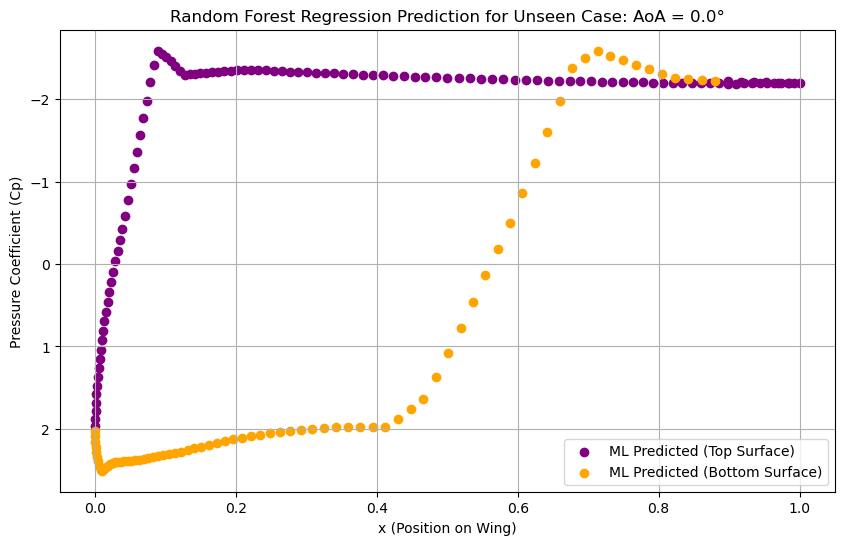

In [48]:
predict_aoa = 180

X_new = full_data[full_data['AoA'] == 0.0][features].copy()
X_new = X_new.reset_index(drop=True)
X_new['AoA'] = predict_aoa
# predict
Cp_predicted = final_model.predict(X_new)

# map back — just attach prediction to the same rows
result = X_new[['x', 'y', 'AoA']].copy()
result['Cp_predicted'] = Cp_predicted

# print(result)


plt.figure(figsize=(10, 6))
top_surface = result[result['y'] > 0].sort_values(by='x')
bottom_surface = result[result['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Random Forest Regression Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()